In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import os
import matplotlib.font_manager as fm
import yfinance as yf
import datetime
from datetime import timedelta, datetime
import pptx as pptx
from openpyxl import load_workbook
from openpyxl.utils.dataframe import dataframe_to_rows
import xlwings as xw

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)

In [2]:
#============== CAMINHO DAS PASTAS ==============#
caminho_planilhas = r'G:\\.shortcut-targets-by-id\\1YZLLTFOuLniE6hO7WNHXl2c3MSa4TOv6\\X. GAME11\\GUARDIAN Institucional\\5. Planejamento & Processos\\2. 2023\\4. Research\\2026\\17. Projetos\\3. Zeladoria' 

#============== FONTES ==============#
caminho_Avenir = r'C:\\Users\\LucasCavalcante\\AppData\\Local\\Microsoft\\Windows\\Fonts\\Avenir Next LT Pro Regular.otf'
caminho_Geometeos = r'C:\\Users\\LucasCavalcante\\AppData\\Local\\Microsoft\\Windows\\Fonts\\Geometos Rounded.ttf'

#============== INSTALANDO AS FONTES ==============#
Avenir = fm.FontProperties(fname=caminho_Avenir)
Geometeos = fm.FontProperties(fname=caminho_Geometeos)

#============== FORCANDO O RECONHECIMENTO DAS FONTES ==============#
plt.rcParams['font.family'] = Avenir.get_name()
plt.rcParams['font.family'] = Avenir.get_name()

#============== TRANSFORMANDO A PLANILHA EM DATAFRAMES ==============#
roo = pd.read_excel(f"{caminho_planilhas}\\ROO_abr26.xlsx")
status_imoveis = pd.read_excel(f"{caminho_planilhas}\\status_imoveis_abr26.xlsx", sheet_name="Cadastral")

In [3]:
#==========================================#
#    LIMPANDO E EDITANDO OS DATAFRAMES
#==========================================#

#============== DATAFRAME DE ROTINAS ORDINARIAS (ROO) ==============#
df_roo = roo.drop(columns = ['Identificação da tarefa', 'Prioridade', 'Atribuído a', 
                             'Criado por', 'Criado em', 'Data de início', 
                             'É Recorrente', 'Concluída por', 'Itens concluídos da lista de verificação',
                              'Itens da lista de verificação', 'Descrição'])

df_roo = df_roo.rename(columns = {'Nome da tarefa':'Tarefa', 'Nome do Bucket':'Imovel', 
                                  'Data de conclusão':'Data_de_conclusao', 'Concluído em':'Concluido_em',
                                  'Rótulos':'Rotulos'})

df_roo['Data_de_conclusao'] = pd.to_datetime(
    df_roo['Data_de_conclusao'],
    format='%d/%m/%Y',
    errors='coerce'
)


#============== DATAFRAME DE STATUS IMÓVEIS ==============#
df_status_imoveis = status_imoveis.drop(columns = ['Observação'])

df_status_imoveis = df_status_imoveis.rename(columns={'imóveis':'Imoveis', 'Projeto Aprovado':'Projeto_Aprovado', 
                                                   'Construção Regularizada':'Construcao_Regularizada', 'Terreno Regularizado':'Terreno_regularizado', 
                                                   'Matricula c/ Construção Averbada':'Matricula_averbada', 'Alienação Averbada':'Alienacao_Averbada',
                                                   'Matricula Atualizada Completa':'Matricula_att_completa', 'Area construida (m²)':'Area_Construida',})

df_status_imoveis['Aluguel'] = (df_status_imoveis['Aluguel']/100).round(2)


In [4]:
df_roo

,Tarefa,Imovel,Progresso,Data_de_conclusao,Atrasados,Concluido_em,Rotulos
0,Visita Imóvel,GPA - BUZIOS,Concluída,2024-11-14,False,25/11/2024,Visita de Imóvel
1,ARARAQUARA - ALU,CARREFOUR - ATC 145 (ARARAQUARA),Concluída,2025-02-15,False,05/02/2025,Aluguel
2,Seguro Patrimonial e de Perdas e Receitas,ALMANARA,Concluída,2024-01-31,False,17/05/2024,Seguro
3,ALMANARA - JANDIRA - ALU,ALMANARA,Concluída,2025-07-15,False,07/07/2025,Aluguel
4,CARAGUATATUBA - ALU,CARREFOUR - ATC 195 (CARAGUATATUBA),Concluída,2025-01-15,False,13/01/2025,Aluguel
...,...,...,...,...,...,...,...
2408,SICREDI - SARANDI (SEDE) - ALU,SICREDI - SARANDI (SEDE),Concluída,2025-07-15,False,03/07/2025,Aluguel
2409,MARINGÁ - ALU,CARREFOUR - ATC 42 (MARINGÁ FERN DIAS),Concluída,2025-12-15,False,08/12/2025,Aluguel
2410,BOA VISTA - ALU,CARREFOUR - ATC 179 (BOA VISTA),Concluída,2025-04-15,False,11/04/2025,Aluguel
2411,MELI - ALU,CONFINS - MELI,Concluída,2026-02-10,False,09/02/2026,Aluguel


In [5]:
aluguel_total = df_status_imoveis['Aluguel'].sum()
consolidado_aluguel = df_status_imoveis.groupby(by = ['Grupo'])['Aluguel'].sum().reset_index()
consolidado_aluguel['% TOTAL'] = ((consolidado_aluguel['Aluguel']/aluguel_total)*100).round(2)
consolidado_aluguel

,Grupo,Aluguel,% TOTAL
0,ARTEMIS24,13761.93,5.03
1,BRL VI,7336.06,2.68
2,GARE,132754.03,48.56
3,GOPT,49291.69,18.03
4,IRIS,16102.66,5.89
5,XPRI,54160.95,19.81


findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Aveni

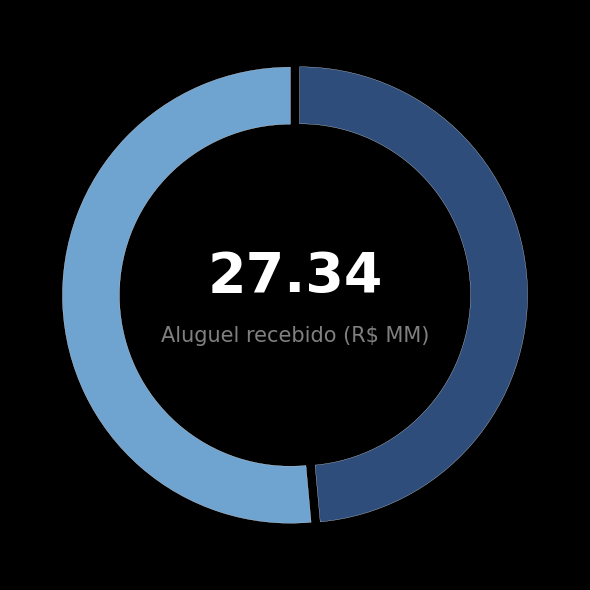

In [6]:

# ──────────────────────────────────────────────
# 1. DADOS
# Recriamos o DataFrame exatamente como você tem
# ──────────────────────────────────────────────
df = pd.DataFrame({
    'Grupo':   ['ARTEMIS24', 'BRL VI', 'GARE', 'GOPT', 'IRIS', 'XPRI'],
    'Aluguel': [13761.93, 7336.06, 132754.03, 49291.69, 16102.66, 54160.95],
    '% TOTAL': [5.03, 2.68, 48.56, 18.03, 5.89, 19.81]
})

# ──────────────────────────────────────────────
# 2. SEPARAÇÃO DOS VALORES
# Isolamos o GARE e somamos todos os demais.
# Usamos .loc para filtrar por nome de grupo —
# mais seguro do que filtrar por índice.
# ──────────────────────────────────────────────
valor_gare   = df.loc[df['Grupo'] == 'GARE', 'Aluguel'].values[0]
valor_outros = df.loc[df['Grupo'] != 'GARE', 'Aluguel'].sum()

total = valor_gare + valor_outros   # para calcular % na legenda
total_ajustado = (total/10000).round(2)

labels = ['GARE', 'Outros Fundos']
values = [valor_gare, valor_outros]

# ──────────────────────────────────────────────
# 3. ESTILO VISUAL
# Duas cores azuis retiradas da paleta da imagem:
#   - azul escuro  → GARE  (fatia maior)
#   - azul claro   → Outros
# startangle=90  → começa no topo, igual à imagem
# counterclock=False → sentido horário
# ──────────────────────────────────────────────
colors     = ['#2E4D7B', '#6FA3D0']   # escuro, claro
explode    = (0.02, 0.02)              # leve separação entre as fatias

fig, ax = plt.subplots(figsize=(6, 6), facecolor='black')
ax.set_facecolor('black')

wedges, texts = ax.pie(
    values,
    labels=None,                  # legenda manual abaixo
    colors=colors,
    explode=explode,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(
        width=0.25,               # espessura do anel — aumentar = mais cheio
        edgecolor='white',
        linewidth=0.2
    )
)


# ──────────────────────────────────────────────
# 4. TOTAL NO CENTRO DO DONUT
# ──────────────────────────────────────────────
ax.text(0, 0.08, str(total_ajustado),
        ha='center', va='center',
        fontsize=40, fontweight='bold', color='white')

ax.text(0, -0.18, 'Aluguel recebido (R$ MM)',
        ha='center', va='center',
        fontsize=15, color='gray')


plt.tight_layout()
plt.savefig('donut_gare.png', transparent = True, dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ──────────────────────────────────────────────
# 1. FILTRO DE ABRIL DE 2026
# Com a coluna em datetime, filtramos por mês e
# ano usando os acessores .dt.month e .dt.year
# ──────────────────────────────────────────────
df_abril = df_roo[
    (df_roo['Data_de_conclusao'].dt.month == 4) &
    (df_roo['Data_de_conclusao'].dt.year  == 2026)
].copy()

# ──────────────────────────────────────────────
# 2. RESULTADO
# ──────────────────────────────────────────────
df_abril_progresso = df_abril.drop(columns=['Tarefa','Imovel','Atrasados','Concluido_em','Rotulos'])

df_abril_progresso = df_abril_progresso.groupby(by=['Progresso']).count()
df_abril_progresso

,Data_de_conclusao
Progresso,
Concluída,79
Não iniciado,7


findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Aveni

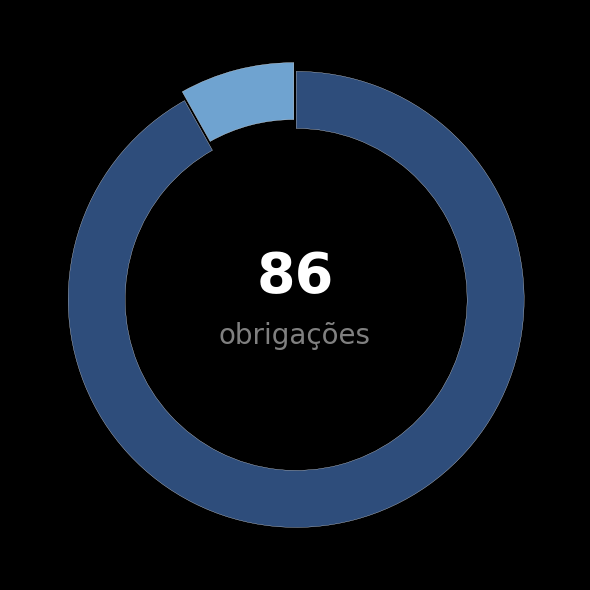

In [8]:
# ──────────────────────────────────────────────
# 1. EXTRAINDO OS VALORES DO DATAFRAME
# Após o groupby, os status viraram índice e a
# contagem ficou na coluna Data_de_conclusao.
# Buscamos cada valor pelo índice nomeado.
# ──────────────────────────────────────────────
valor_concluida    = df_abril_progresso.loc['Concluída',    'Data_de_conclusao']
valor_nao_iniciado = df_abril_progresso.loc['Não iniciado', 'Data_de_conclusao']

total  = valor_concluida + valor_nao_iniciado
labels = ['Concluída', 'Não iniciado']
values = [valor_concluida, valor_nao_iniciado]

# ──────────────────────────────────────────────
# 2. GRÁFICO
# Mesma estrutura do donut anterior — apenas
# adaptamos labels, valores e cores.
# Verde para Concluída, laranja para Não iniciado
# ──────────────────────────────────────────────
colors  = ['#2E4D7B', '#6FA3D0']
explode = (0.02, 0.02)

fig, ax = plt.subplots(figsize=(6, 6), facecolor='black')
ax.set_facecolor('black')

wedges, texts = ax.pie(
    values,
    labels=None,
    colors=colors,
    explode=explode,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(
        width=0.25,
        edgecolor='white',
        linewidth=0.2
    )
)

# ──────────────────────────────────────────────
# 5. TOTAL NO CENTRO DO DONUT
# ──────────────────────────────────────────────
ax.text(0, 0.08, str(total),
        ha='center', va='center',
        fontsize=40, fontweight='bold', color='white')

ax.text(0, -0.18, 'obrigações',
        ha='center', va='center',
        fontsize=20, color='gray')


plt.tight_layout()
plt.savefig('donut_progresso_abril.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

In [9]:
df_abril_rotulos = df_abril.drop(columns=['Tarefa', 'Imovel', 'Data_de_conclusao', 'Atrasados', 'Concluido_em'])
df_abril_rotulos = df_abril_rotulos.groupby(by = ['Rotulos', 'Progresso'],as_index=False).size().rename(columns={'size':'Quantidade'})
df_abril_rotulos

,Rotulos,Progresso,Quantidade
0,Aluguel,Concluída,72
1,Carta Fiança,Concluída,2
2,IPTU,Concluída,1
3,IPTU,Não iniciado,4
4,Reajuste de Aluguel,Não iniciado,3
5,Seguro,Concluída,4


findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Aveni

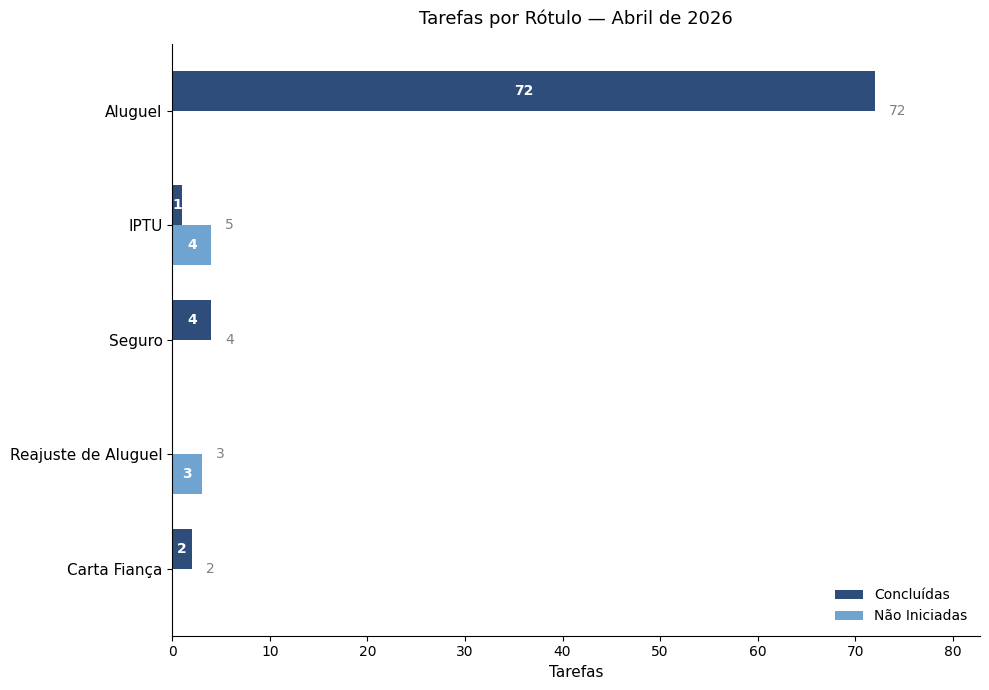

In [10]:
# ──────────────────────────────────────────────
# 1. PREPARAÇÃO DOS DADOS
# Precisamos "pivotar" o dataframe para que cada
# status vire uma coluna — facilita o plot agrupado
# fill_value=0 garante que combinações inexistentes
# (ex: Carta Fiança + Não iniciado) fiquem como 0
# ──────────────────────────────────────────────
df_pivot = df_abril_rotulos.pivot(
    index='Rotulos',
    columns='Progresso',
    values='Quantidade'
).fillna(0).astype(int)

# Garante que as duas colunas sempre existam
for col in ['Concluída', 'Não iniciado']:
    if col not in df_pivot.columns:
        df_pivot[col] = 0

# Ordena pelo total para ficar visualmente organizado
df_pivot['Total'] = df_pivot['Concluída'] + df_pivot['Não iniciado']
df_pivot = df_pivot.sort_values('Total', ascending=True).drop(columns='Total')

# ──────────────────────────────────────────────
# 2. CONFIGURAÇÕES VISUAIS
# Mesmas cores dos donuts:
#   azul escuro → Concluída
#   azul claro  → Não iniciado
# ──────────────────────────────────────────────
cores = {
    'Concluída':    '#2E4D7B',
    'Não iniciado': '#6FA3D0'
}

rotulos     = df_pivot.index.tolist()
concluidas  = df_pivot['Concluída'].tolist()
nao_inic    = df_pivot['Não iniciado'].tolist()
n           = len(rotulos)

# Espaçamento entre grupos de barras
altura      = 0.35
posicoes    = np.arange(n)

# ──────────────────────────────────────────────
# 3. FIGURA E EIXOS
# figsize ajusta altura dinamicamente conforme
# a quantidade de rótulos no dataframe
# ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, n * 1.1 + 1.5), facecolor='white')
ax.set_facecolor('white')

# ──────────────────────────────────────────────
# 4. BARRAS
# Plotamos as duas séries deslocadas em y para
# ficarem lado a lado (agrupadas)
# ──────────────────────────────────────────────
barras_conc = ax.barh(
    posicoes + altura / 2,
    concluidas,
    height=altura,
    color=cores['Concluída'],
    label='Concluídas'
)

barras_nao = ax.barh(
    posicoes - altura / 2,
    nao_inic,
    height=altura,
    color=cores['Não iniciado'],
    label='Não Iniciadas'
)

# ──────────────────────────────────────────────
# 5. RÓTULOS DENTRO DAS BARRAS + TOTAL AO LADO
# Valor dentro da barra (branco) apenas se > 0
# Total ao lado direito (cinza claro), igual
# à imagem de referência
# ──────────────────────────────────────────────
total_max = max([c + n_ for c, n_ in zip(concluidas, nao_inic)])

for i, (c, ni) in enumerate(zip(concluidas, nao_inic)):
    total = c + ni

    # Valor dentro da barra Concluída
    if c > 0:
        ax.text(c / 2, i + altura / 2, str(c),
                va='center', ha='center',
                fontsize=10, fontweight='bold', color='white')

    # Valor dentro da barra Não iniciado
    if ni > 0:
        ax.text(ni / 2, i - altura / 2, str(ni),
                va='center', ha='center',
                fontsize=10, fontweight='bold', color='white')

    # Total ao lado direito
    ax.text(max(c, ni) + total_max * 0.02, i, str(total),
            va='center', ha='left',
            fontsize=10, color='gray')

# ──────────────────────────────────────────────
# 6. EIXOS E ESTILO
# ──────────────────────────────────────────────
ax.set_yticks(posicoes)
ax.set_yticklabels(rotulos, fontsize=11)
ax.set_xlabel('Tarefas', fontsize=11)
ax.set_xlim(0, total_max * 1.15)   # margem para o total ao lado

# Remove bordas desnecessárias — visual limpo
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ──────────────────────────────────────────────
# 7. LEGENDA E TÍTULO
# ──────────────────────────────────────────────
ax.legend(
    loc='lower right',
    frameon=False,
    fontsize=10
)

ax.set_title('Tarefas por Rótulo — Abril de 2026', fontsize=13, pad=14)

plt.tight_layout()
plt.savefig('barras_rotulos_abril.png', dpi=150, bbox_inches='tight', transparent = True)
plt.show()

In [11]:
df_abril_reajustes = df_abril.query('Rotulos == "Reajuste de Aluguel"').drop(columns=['Tarefa', 'Atrasados', 'Concluido_em', 'Rotulos']).rename(columns={'Data_de_conclusao':'Vencimento'})
df_abril_reajustes


,Imovel,Progresso,Vencimento
681,MATEUS - TIMON,Não iniciado,2026-04-22
1030,MATEUS - SOUSA,Não iniciado,2026-04-22
2144,MATEUS - JACOBINA,Não iniciado,2026-04-22


In [12]:
regularizacao_cadastral = df_status_imoveis.drop(columns=['Imoveis','Aluguel','Tipo do Contrato', 'Vencimento do Contrato', 'Area_Construida', 'Alienacao_Averbada', 'Matricula_att_completa'])
regularizacao_cadastral

,Grupo,Projeto_Aprovado,Construcao_Regularizada,Terreno_regularizado,Matricula_averbada
0,GARE,Não,Ok,Ok,Não
1,GARE,Ok,Parcial,Ok,Parcial
2,GARE,Ok,Ok,Ok,Ok
3,GARE,Ok,Ok,Ok,Ok
4,XPRI,Ok,Ok,Ok,Não
...,...,...,...,...,...
71,GOPT,Ok,Ok,Ok,Ok
72,GARE,Ok,Ok,Ok,Ok
73,GARE,Ok,Ok,Ok,Ok
74,GARE,Ok,Ok,Ok,Ok


findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Aveni

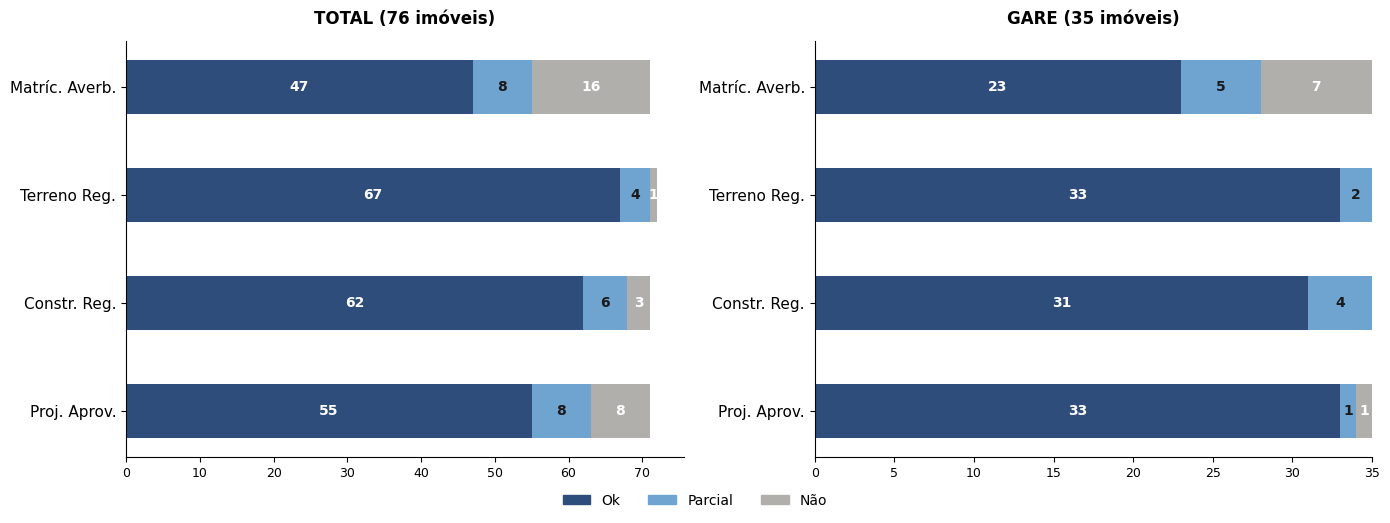

In [13]:
# ──────────────────────────────────────────────
# 1. CONFIGURAÇÕES GERAIS
# Mapeamento de cores seguindo o padrão da imagem:
#   Ok      → azul escuro  (nossa cor principal)
#   Parcial → azul claro   (nossa cor secundária)
#   Não     → cinza        (neutro)
# ──────────────────────────────────────────────
colunas = {
    'Projeto_Aprovado':        'Proj. Aprov.',
    'Construcao_Regularizada': 'Constr. Reg.',
    'Terreno_regularizado':    'Terreno Reg.',
    'Matricula_averbada':      'Matríc. Averb.'
}

categorias = ['Ok', 'Parcial', 'Não']

cores = {
    'Ok':      '#2E4D7B',
    'Parcial': '#6FA3D0',
    'Não':     '#B0AFAB'
}


# ──────────────────────────────────────────────
# 2. FUNÇÃO DE CONTAGEM
# Recebe um DataFrame (total ou filtrado por grupo)
# e retorna um DataFrame com a contagem de cada
# categoria por coluna — ignorando NaN
# ──────────────────────────────────────────────
def contar_categorias(df_input):
    resultado = {}
    for col in colunas.keys():
        contagem = df_input[col].value_counts(dropna=True)
        resultado[col] = {cat: contagem.get(cat, 0) for cat in categorias}
    return pd.DataFrame(resultado).T   # linhas = colunas, colunas = categorias


# ──────────────────────────────────────────────
# 3. DATAFRAMES DE CADA PAINEL
# df_total  → todos os imóveis
# df_gare   → apenas grupo GARE
# ──────────────────────────────────────────────
df_total = contar_categorias(regularizacao_cadastral)
df_gare  = contar_categorias(regularizacao_cadastral[regularizacao_cadastral['Grupo'] == 'GARE'])

n_total = len(regularizacao_cadastral)
n_gare  = len(regularizacao_cadastral[regularizacao_cadastral['Grupo'] == 'GARE'])


# ──────────────────────────────────────────────
# 4. FUNÇÃO DE PLOT
# Centraliza a lógica de desenho para não
# repetir código nos dois painéis
# ──────────────────────────────────────────────
def plotar_painel(ax, df_plot, titulo):
    rotulos_y = [colunas[c] for c in df_plot.index]
    n         = len(rotulos_y)
    altura    = 0.5

    # Acumula a posição horizontal para empilhar
    acumulado = np.zeros(n)

    for cat in categorias:
        valores = df_plot[cat].values

        barras = ax.barh(
            range(n),
            valores,
            left=acumulado,
            height=altura,
            color=cores[cat],
            label=cat
        )

        # Valor dentro de cada segmento
        # Só exibe se o segmento for largo o suficiente
        for i, (val, esq) in enumerate(zip(valores, acumulado)):
            if val > 0:
                ax.text(
                    esq + val / 2, i, str(val),
                    va='center', ha='center',
                    fontsize=10, fontweight='bold',
                    color='white' if cat in ['Ok', 'Não'] else '#1a1a1a'
                )

        acumulado += valores

    # ──────────────────────────────────────────
    # ESTILO DO PAINEL
    # ──────────────────────────────────────────
    ax.set_yticks(range(n))
    ax.set_yticklabels(rotulos_y, fontsize=11)
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=9)


# ──────────────────────────────────────────────
# 5. FIGURA COM 2 PAINÉIS LADO A LADO
# ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 5),
    facecolor='white'
)
ax1.set_facecolor('white')
ax2.set_facecolor('white')

plotar_painel(ax1, df_total, f'TOTAL ({n_total} imóveis)')
plotar_painel(ax2, df_gare,  f'GARE ({n_gare} imóveis)')

# ──────────────────────────────────────────────
# 6. LEGENDA COMPARTILHADA
# Uma única legenda para os dois painéis,
# posicionada abaixo da figura
# ──────────────────────────────────────────────
handles = [
    plt.Rectangle((0,0), 1, 1, color=cores[cat], label=cat)
    for cat in categorias
]

fig.legend(
    handles=handles,
    loc='lower center',
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()
plt.savefig('regularizacao_cadastral.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [14]:
# ──────────────────────────────────────────────
#    PERCENTUAL DE CONCLUSÃO DAS OBRIGAÇÕES
# ──────────────────────────────────────────────

# ──────────────────────────────────────────────
# 1. FUNÇÃO DE PERCENTUAL DE OK
# Recebe um DataFrame e retorna o % de 'Ok'
# em relação ao total de não-nulos por coluna
# ──────────────────────────────────────────────
def percentual_ok(df_input):
    resultado = {}
    for col in colunas.keys():
        serie      = df_input[col].dropna()
        total      = len(serie)
        qtd_ok     = (serie == 'Ok').sum()
        resultado[colunas[col]] = f"{round(qtd_ok / total * 100)}%" if total > 0 else "—"
    return resultado


# ──────────────────────────────────────────────
# 2. CALCULA PARA TOTAL E GARE
# ──────────────────────────────────────────────
pct_total = percentual_ok(regularizacao_cadastral)
pct_gare  = percentual_ok(regularizacao_cadastral[regularizacao_cadastral['Grupo'] == 'GARE'])


# ──────────────────────────────────────────────
# 3. MONTA O DATAFRAME DA TABELA
# ──────────────────────────────────────────────
df_tabela = pd.DataFrame({
    'TOTAL': pct_total,
    'GARE':  pct_gare
})

df_tabela

,TOTAL,GARE
Proj. Aprov.,77%,94%
Constr. Reg.,87%,89%
Terreno Reg.,93%,94%
Matríc. Averb.,66%,66%


In [15]:
# ──────────────────────────────────────────────
# 1. FILTRO DE JANEIRO A ABRIL DE 2026
# Com a coluna em datetime, filtramos por mês e
# ano usando os acessores .dt.month e .dt.year
# ──────────────────────────────────────────────
data_inicio = pd.Timestamp('2026-01-01')
data_fim = pd.Timestamp('2026-04-30')


df_jan_abr = df_roo[
    df_roo['Data_de_conclusao'].between(data_inicio, data_fim)
].copy().query('Atrasados == True').drop(columns = ['Tarefa', 'Imovel', 'Progresso', 'Data_de_conclusao', 'Concluido_em']).groupby('Rotulos')['Atrasados'].count().reset_index()
df

df_jan_abr

,Rotulos,Atrasados
0,AVCB,3
1,IPTU,6
2,Não Ocorrência de Recompra,14
3,Reajuste de Aluguel,3
4,Seguro,31
5,Taxa de Bombeiro,1


findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Avenir Next LT Pro' not found.
findfont: Font family 'Aveni

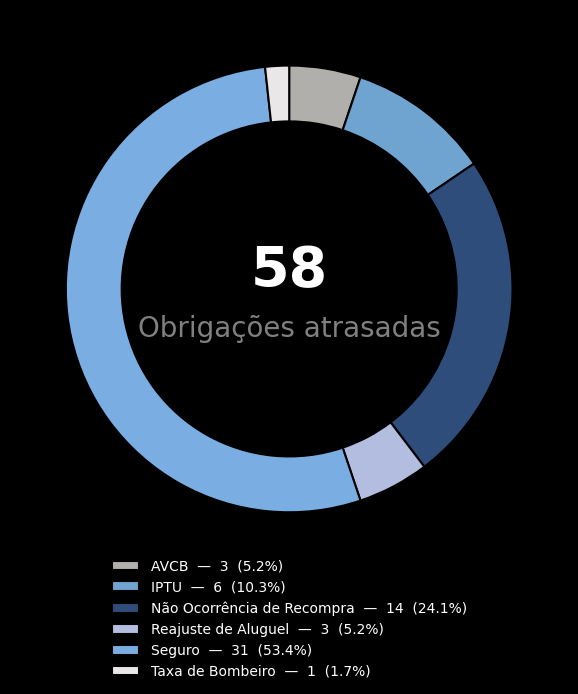

In [16]:
# ──────────────────────────────────────────────
# 1. DADOS
# ──────────────────────────────────────────────
labels = df_jan_abr['Rotulos'].tolist()
values = df_jan_abr['Atrasados'].tolist()
total  = sum(values)

# ──────────────────────────────────────────────
# 2. CORES
# Uma cor da paleta para cada fatia —
# mesma ordem das linhas do dataframe
# ──────────────────────────────────────────────
cores = ['#B0AFAB', '#6FA3D0', '#2E4D7B', '#B2BDDF', '#7AAEE2', '#EAE7E8']

# ──────────────────────────────────────────────
# 3. FIGURA
# ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7), facecolor='black')
ax.set_facecolor('black')

wedges, texts = ax.pie(
    values,
    labels=None,
    colors=cores,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(
        width=0.25,
        edgecolor='black',
        linewidth=1.5
    )
)

# ──────────────────────────────────────────────
# 4. LEGENDA
# Rótulo | quantidade | % do total
# ──────────────────────────────────────────────
legend_labels = [
    f"{lbl}  —  {val}  ({val/total*100:.1f}%)"
    for lbl, val in zip(labels, values)
]

ax.legend(
    wedges,
    legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.22),
    frameon=False,
    fontsize=10,
    labelcolor='white'
)

# ──────────────────────────────────────────────
# 5. TOTAL NO CENTRO DO DONUT
# ──────────────────────────────────────────────
ax.text(0, 0.08, str(total),
        ha='center', va='center',
        fontsize=40, fontweight='bold', color='white')

ax.text(0, -0.18, 'Obrigações atrasadas',
        ha='center', va='center',
        fontsize=20, color='gray')

plt.tight_layout()
plt.savefig('donut_atrasados.png', dpi=150, bbox_inches='tight', transparent = True)
plt.show()

In [ ]:
df_averb = df_status_imoveis.drop(columns=['Aluguel', 'Tipo do Contrato', 'Vencimento do Contrato',
                                           'Projeto_Aprovado', 'Construcao_Regularizada', 'Terreno_regularizado',
                                           'Alienacao_Averbada', 'Matricula_att_completa', 'Area_Construida']).query('Matricula_averbada != "Ok"').dropna()
df_averb

,Imoveis,Grupo,Matricula_averbada
0,AIRLIQUID CANOAS,GARE,Não
1,AIRLIQUID SÃO JOSÉ DOS CAMPOS,GARE,Parcial
4,BRF SALVADOR,XPRI,Não
5,BRF VISA,IRIS,Parcial
7,BRL VI - ARTERIS (RIBERÃO),BRL VI,Parcial
25,CARREFOUR - ATC 42 (MARINGÁ FERN DIAS),GARE,Parcial
26,CARREFOUR - ATC 45 (CUIABÁ TIJ),GARE,Parcial
27,GPA - ABILIO SOARES,GARE,Não
28,GPA - ANGÉLICA,GARE,Não
29,GPA - BUZIOS,GARE,Não


In [24]:
# ──────────────────────────────────────────────
# 1. FILTRO DE MAIO DE 2026
# Com a coluna em datetime, filtramos por mês e
# ano usando os acessores .dt.month e .dt.year
# ──────────────────────────────────────────────
df_maio = df_roo[
    (df_roo['Data_de_conclusao'].dt.month == 5) &
    (df_roo['Data_de_conclusao'].dt.year  == 2026)
].copy()

# ──────────────────────────────────────────────
# 2. RESULTADO
# ──────────────────────────────────────────────
df_maio_tarefas = df_maio.drop(columns=['Tarefa','Imovel','Atrasados','Concluido_em']).query('Rotulos != "Aluguel"').groupby(by = ['Rotulos', 'Progresso']).count()
df_maio_tarefas

Data_de_conclusao
Rotulos             Progresso                      
AVCB                Concluída                     3
                    Não iniciado                  6
Avaliação de Imóvel Não iniciado                 23
IPTU                Concluída                     1
                    Não iniciado                  9
Reajuste de Aluguel Não iniciado                  2
Seguro              Não iniciado                  1